## to make solutions out of gemini output

In [2]:
import os
import json

def create_solution_jsons(input_file_path, output_directory):
    """
    Create individual solution JSON files for each question in the input JSON.
    """
    try:
        # Read the input JSON file
        with open(input_file_path, 'r', encoding='utf-8') as file:
            data = json.load(file)
        
        # Extract the folder name from the file path
        # Get the parent directory of the json folder (e.g., 01_10021008481039611101693742355)
        folder_path = os.path.dirname(os.path.dirname(input_file_path))
        folder_name = os.path.basename(folder_path)
        
        # Extract the first part of the directory name (before the first '_')
        folder_prefix = folder_name.split('_')[0]  # Gets the first part before '_'
        
        # Define output folder
        output_folder = os.path.join(output_directory, folder_name)
        os.makedirs(output_folder, exist_ok=True)
        
        print(f"Processing folder: {folder_name}")
        print(f"Output directory: {output_folder}")
        
        # Loop through each question and create a new JSON for each
        for entry in data:
            question_number = entry.get('question_number')
            solution = [{
                "question_number": question_number,
                "solution_text": entry.get('solution_text'),
                "diagrams": entry.get('diagrams', []),
                "pages": entry.get('pages', [])
            }]
            
            # Define the solution file path with the new naming convention
            solution_file_path = os.path.join(output_folder, f"{folder_prefix}_solution_{question_number}.json")
            
            # Write the solution JSON to the file
            with open(solution_file_path, 'w', encoding='utf-8') as solution_file:
                json.dump(solution, solution_file, indent=2, ensure_ascii=False)
            
            print(f"  ✅ Solution {question_number} saved: {solution_file_path}")
    
    except Exception as e:
        print(f"❌ Error processing file {input_file_path}: {e}")

def process_output_directory(input_directory, output_directory):
    """
    Process all output_with_questions.json files in the specified directory structure.
    """
    processed_count = 0
    error_count = 0
    
    print(f"🔍 Scanning directory: {input_directory}")
    print(f"📂 Output will be saved to: {output_directory}")
    print("=" * 60)
    
    # Walk through all subdirectories
    for root, dirs, files in os.walk(input_directory):
        # Look for the specific file pattern: */json/output_with_questions.json
        if 'output_with_questions.json' in files and root.endswith('json'):
            file_path = os.path.join(root, 'output_with_questions.json')
            print(f"📄 Found: {file_path}")
            
            try:
                create_solution_jsons(file_path, output_directory)
                processed_count += 1
            except Exception as e:
                print(f"❌ Error processing {file_path}: {e}")
                error_count += 1
    
    print("=" * 60)
    print(f"📊 PROCESSING SUMMARY:")
    print(f"✅ Successfully processed: {processed_count} files")
    print(f"❌ Errors encountered: {error_count} files")
    print("=" * 60)

def main():
    """
    Main function to run the solution creation process.
    """
    print("🎯 Chemistry Solution JSON Creator")
    print("=" * 60)
    
    # Input directory containing the output folders
    input_directory = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/output"
    
    # Output directory where solutions will be saved
    output_directory = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/Physics_Gemini/solutions"
    
    # Verify input directory exists
    if not os.path.exists(input_directory):
        print(f"❌ Input directory does not exist: {input_directory}")
        return
    
    # Create output directory if it doesn't exist
    os.makedirs(output_directory, exist_ok=True)
    
    print(f"📂 Input directory:  {input_directory}")
    print(f"📂 Output directory: {output_directory}")
    
    # Process all files
    process_output_directory(input_directory, output_directory)

if __name__ == "__main__":
    main()

🎯 Chemistry Solution JSON Creator
📂 Input directory:  /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/output
📂 Output directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/Physics_Gemini/solutions
🔍 Scanning directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/output
📂 Output will be saved to: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/Physics_Gemini/solutions
📄 Found: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/output/12_1002140198994121111692513661/json/output_with_questions.json
Processing folder: 12_1002140198994121111692513661
Output directory: /Users/simrannaik/Deskto

## make a table first

In [3]:
import os
import json

class OCRComparator:
    def __init__(self, human_dir, gemini_dir, output_dir):
        """
        Initialize with just 3 base directories
        """
        self.human_dir = human_dir
        self.gemini_dir = gemini_dir  
        self.output_dir = output_dir
        
        print(f"📁 Human OCR directory:  {self.human_dir}")
        print(f"🤖 Gemini OCR directory: {self.gemini_dir}")
        print(f"💾 Output directory:     {self.output_dir}")
        print("=" * 70)
    
    def compare_solution_files(self, solution_folder, solution_number, file_prefix):
        """
        Compare a single solution file between human and Gemini OCR
        """
        # Build file paths using the base directories
        human_file = os.path.join(
            self.human_dir, solution_folder, f"{file_prefix}_solution_{solution_number}.json"
        )
        
        gemini_file = os.path.join(
            self.gemini_dir, solution_folder, f"{file_prefix}_solution_{solution_number}.json"
        )
        
        output_file = os.path.join(
            self.output_dir, solution_folder, f"{file_prefix}_solution_{solution_number}_table.json"
        )
        
        print(f"🔄 Processing solution {solution_number} in {solution_folder}")
        
        # Initialize combined data structure
        combined_data = {
            "question_number": solution_number,
            "human_text": "NA",
            "ocr_text": "NA",
            "ocr_pages": [],
            "pdf_name": solution_folder  # Add pdf source info
        }
        
        # Read Human OCR data
        if os.path.exists(human_file):
            try:
                with open(human_file, 'r', encoding='utf-8') as f:
                    human_data = json.load(f)
                    
                if isinstance(human_data, list) and len(human_data) > 0:
                    human_item = human_data[0]
                    combined_data["human_text"] = human_item.get('solution_text', 'NA')
                    combined_data["question_number"] = human_item.get('question_number', solution_number)
                    print(f"   ✅ Human text loaded: {len(str(combined_data['human_text']))} chars")
                else:
                    print(f"   ⚠️  Human file format issue: {human_file}")
                    
            except Exception as e:
                print(f"   ❌ Error reading human file: {e}")
        else:
            print(f"   ❌ Human file not found: {human_file}")
        
        # Read Gemini OCR data
        if os.path.exists(gemini_file):
            try:
                with open(gemini_file, 'r', encoding='utf-8') as f:
                    gemini_data = json.load(f)
                    
                if isinstance(gemini_data, list) and len(gemini_data) > 0:
                    gemini_item = gemini_data[0]
                    combined_data["ocr_text"] = gemini_item.get('solution_text', 'NA')
                    combined_data["ocr_pages"] = gemini_item.get('pages', [])
                    print(f"   ✅ Gemini text loaded: {len(str(combined_data['ocr_text']))} chars")
                    print(f"   📄 Pages: {combined_data['ocr_pages']}")
                else:
                    print(f"   ⚠️  Gemini file format issue: {gemini_file}")
                    
            except Exception as e:
                print(f"   ❌ Error reading Gemini file: {e}")
        else:
            print(f"   ❌ Gemini file not found: {gemini_file}")
        
        # Save combined data
        os.makedirs(os.path.dirname(output_file), exist_ok=True)
        
        try:
            with open(output_file, 'w', encoding='utf-8') as f:
                json.dump(combined_data, f, indent=2, ensure_ascii=False)
            print(f"   💾 Saved: {os.path.basename(output_file)}")
            return True
        except Exception as e:
            print(f"   ❌ Error saving output: {e}")
            return False
    
    def process_all_solutions(self):
        """
        Process all solution folders and files
        """
        if not os.path.exists(self.human_dir):
            print(f"❌ Human directory not found: {self.human_dir}")
            return
            
        total_processed = 0
        successful = 0
        errors = 0
        
        print(f"🔍 Scanning human directory: {self.human_dir}")
        
        # Iterate through all solution folders
        for solution_folder in os.listdir(self.human_dir):
            solution_folder_path = os.path.join(self.human_dir, solution_folder)
            
            if not os.path.isdir(solution_folder_path):
                continue
                
            print(f"\n📂 Processing folder: {solution_folder}")
            
            # Process all JSON files in this folder
            for filename in os.listdir(solution_folder_path):
                if filename.endswith('.json') and '_solution_' in filename:
                    try:
                        # Parse filename to extract prefix and solution number
                        file_prefix = filename.split('_solution_')[0]
                        solution_number = int(filename.split('_solution_')[1].split('.')[0])
                        
                        total_processed += 1
                        
                        # Compare this solution file
                        success = self.compare_solution_files(solution_folder, solution_number, file_prefix)
                        
                        if success:
                            successful += 1
                        else:
                            errors += 1
                            
                    except Exception as e:
                        print(f"   ❌ Filename parse error for {filename}: {e}")
                        errors += 1
                        total_processed += 1
        
        # Print summary
        print("\n" + "=" * 70)
        print("📊 PROCESSING SUMMARY")
        print("=" * 70)
        print(f"Total files processed: {total_processed}")
        print(f"Successfully compared: {successful}")
        print(f"Errors encountered:    {errors}")
        print(f"Success rate:          {(successful/total_processed)*100:.1f}%" if total_processed > 0 else "N/A")
        print("=" * 70)

def main():
    """
    Main function - define your 3 directories here
    """
    print("🔧 OCR Comparison Tool")
    print("=" * 70)
    
    # ===== DEFINE YOUR 3 DIRECTORIES HERE =====
    base_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb"
    
    human_ocr_dir = os.path.join(base_path, "Physics/Physics_human/solution_chapters")
    gemini_ocr_dir = os.path.join(base_path, "Physics/Physics_Gemini/solutions") 
    output_dir = os.path.join(base_path, "Physics/table")
    
    # ===== END DIRECTORY DEFINITIONS =====
    
    # Create comparator and run
    comparator = OCRComparator(human_ocr_dir, gemini_ocr_dir, output_dir)
    comparator.process_all_solutions()
    
    print("\n✅ OCR comparison complete!")

if __name__ == "__main__":
    main()

🔧 OCR Comparison Tool
📁 Human OCR directory:  /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/Physics_human/solution_chapters
🤖 Gemini OCR directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/Physics_Gemini/solutions
💾 Output directory:     /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/table
🔍 Scanning human directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/Physics_human/solution_chapters

📂 Processing folder: 12_1002140198994121111692513661
🔄 Processing solution 1 in 12_1002140198994121111692513661
   ✅ Human text loaded: 14 chars
   ✅ Gemini text loaded: 14 chars
   📄 Pages: [1]
   💾 Saved: 12_solution_1_table.json
🔄 Processing solution 2 in 12_10021401

## check for na and delete them

In [4]:
import os
import json
from pathlib import Path

def delete_na_json_files(base_path):
    """
    Scan through chemistry table directory and DELETE JSON files with NA values
    in ocr_text or human_text fields
    """
    base_dir = Path(base_path)
    
    if not base_dir.exists():
        print(f"Directory does not exist: {base_path}")
        return
    
    na_files = []
    total_files = 0
    deleted_files = []
    failed_deletions = []
    
    print(f"Scanning directory: {base_path}")
    print("=" * 80)
    
    # Walk through all subdirectories
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.json'):
                file_path = os.path.join(root, file)
                total_files += 1
                
                try:
                    with open(file_path, 'r', encoding='utf-8') as f:
                        data = json.load(f)
                    
                    # Check for NA in ocr_text and human_text
                    ocr_text = data.get('ocr_text', '')
                    human_text = data.get('human_text', '')
                    
                    has_na = False
                    na_fields = []
                    
                    if ocr_text == "NA" or ocr_text is None:
                        has_na = True
                        na_fields.append('ocr_text')
                    
                    if human_text == "NA" or human_text is None:
                        has_na = True
                        na_fields.append('human_text')
                    
                    if has_na:
                        relative_path = os.path.relpath(file_path, base_dir)
                        na_files.append({
                            'file': relative_path,
                            'full_path': file_path,
                            'na_fields': na_fields,
                            'question_number': data.get('question_number', 'Unknown')
                        })
                        
                        # DELETE THE FILE
                        try:
                            os.remove(file_path)
                            deleted_files.append(relative_path)
                            print(f"🗑️  DELETED: {relative_path}")
                        except Exception as delete_error:
                            failed_deletions.append({
                                'file': relative_path,
                                'error': str(delete_error)
                            })
                            print(f"❌ FAILED TO DELETE: {relative_path} - {delete_error}")
                        
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
    
    # Display results
    print("\n" + "=" * 80)
    print(f"DELETION SUMMARY:")
    print("=" * 80)
    print(f"Total JSON files scanned: {total_files}")
    print(f"Files with NA values found: {len(na_files)}")
    print(f"Files successfully deleted: {len(deleted_files)}")
    print(f"Files failed to delete: {len(failed_deletions)}")
    print("=" * 80)
    
    if na_files:
        print(f"\nFiles that contained NA values:")
        print("-" * 80)
        for item in na_files:
            status = "✅ DELETED" if item['file'] in deleted_files else "❌ FAILED"
            print(f"{status}: {item['file']}")
            print(f"Question Number: {item['question_number']}")
            print(f"Fields with NA: {', '.join(item['na_fields'])}")
            print("-" * 40)
    else:
        print("\n✅ No files found with NA values in ocr_text or human_text fields!")
    
    if failed_deletions:
        print(f"\n❌ FAILED DELETIONS:")
        print("-" * 80)
        for failed in failed_deletions:
            print(f"File: {failed['file']}")
            print(f"Error: {failed['error']}")
            print("-" * 40)
    
    return {
        'total_files': total_files,
        'na_files': na_files,
        'deleted_files': deleted_files,
        'failed_deletions': failed_deletions
    }

if __name__ == "__main__":
    # Directory path
    chemistry_table_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics"
    
    print("⚠️  WARNING: This script will DELETE files with NA values!")
    print("Files will be permanently deleted from your system.")
    print("-" * 60)
    
    # Run the deletion
    results = delete_na_json_files(chemistry_table_path)
    
    print(f"\n🎯 FINAL RESULTS:")
    print(f"   • Total files scanned: {results['total_files']}")
    print(f"   • Files deleted: {len(results['deleted_files'])}")
    print(f"   • Failed deletions: {len(results['failed_deletions'])}")

⚠️  WARNING: This script will DELETE files with NA values!
Files will be permanently deleted from your system.
------------------------------------------------------------
Scanning directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics
Error reading /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/output/12_1002140198994121111692513661/json/output_with_questions.json: 'list' object has no attribute 'get'
Error reading /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/output/09_1002114885961841111690700733/json/output_with_questions.json: 'list' object has no attribute 'get'
Error reading /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/output/10_10021138351083421111694954

# # REDUCE EVERYTHING TO CAPITALIZE THE WHOLE .JSON ON BOTH GD AND PREDICTED remove /n <br>

In [5]:
import os
import json
import re
from pathlib import Path

def clean_text(text):
    """
    Clean text by removing <br>, <br/>, \n and converting to lowercase
    """
    if not text or text == "NA":
        return text
    
    # Remove <br> and <br/> tags (case insensitive)
    text = re.sub(r'<br\s*/?>', '', text, flags=re.IGNORECASE)
    
    # Remove \n newline characters
    text = text.replace('\n', '')
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra whitespace that might be left
    text = ' '.join(text.split())
    
    return text

def process_json_file(input_file_path, output_file_path):
    """
    Process a single JSON file - clean text fields and save to output path
    """
    try:
        # Read the input file
        with open(input_file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Clean human_text and ocr_text fields
        if 'human_text' in data:
            original_human = data['human_text']
            data['human_text'] = clean_text(data['human_text'])
            
        if 'ocr_text' in data:
            original_ocr = data['ocr_text']
            data['ocr_text'] = clean_text(data['ocr_text'])
        
        # Ensure output directory exists
        os.makedirs(os.path.dirname(output_file_path), exist_ok=True)
        
        # Save the cleaned data
        with open(output_file_path, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
        
        return True, None
        
    except Exception as e:
        return False, str(e)

def clean_table_json_files(base_path):
    """
    Process all JSON files in the table directory and save cleaned versions
    """
    base_dir = Path(base_path)
    
    if not base_dir.exists():
        print(f"❌ Directory does not exist: {base_path}")
        return
    
    # Create table_format directory
    output_base = base_dir.parent / "table_format"
    
    processed_files = 0
    successful_files = 0
    error_files = []
    
    print(f"🔧 Processing JSON files from: {base_path}")
    print(f"📁 Output directory: {output_base}")
    print("=" * 80)
    
    # Walk through all subdirectories
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.json'):
                input_file_path = os.path.join(root, file)
                
                # Create corresponding output path
                relative_path = os.path.relpath(input_file_path, base_dir)
                output_file_path = output_base / relative_path
                
                processed_files += 1
                
                print(f"🔄 Processing: {relative_path}")
                
                # Process the file
                success, error = process_json_file(input_file_path, output_file_path)
                
                if success:
                    successful_files += 1
                    print(f"✅ Cleaned and saved: {relative_path}")
                else:
                    error_files.append({
                        'file': relative_path,
                        'error': error
                    })
                    print(f"❌ ERROR processing {relative_path}: {error}")
    
    # Display summary
    print("\n" + "=" * 80)
    print(f"📊 PROCESSING SUMMARY:")
    print("=" * 80)
    print(f"Total files processed: {processed_files}")
    print(f"Successfully cleaned: {successful_files}")
    print(f"Errors encountered: {len(error_files)}")
    print(f"Output saved to: {output_base}")
    print("=" * 80)
    
    # Display errors if any
    if error_files:
        print(f"\n❌ ERROR DETAILS:")
        print("-" * 80)
        for error_item in error_files:
            print(f"File: {error_item['file']}")
            print(f"Error: {error_item['error']}")
            print("-" * 40)
    else:
        print("\n🎉 All files processed successfully!")
    
    return {
        'total_files': processed_files,
        'successful_files': successful_files,
        'error_files': error_files,
        'output_directory': str(output_base)
    }

def preview_cleaning(sample_text):
    """
    Show a preview of what the cleaning function does
    """
    print("🔍 CLEANING PREVIEW:")
    print("-" * 50)
    print(f"Original: {repr(sample_text)}")
    print(f"Cleaned:  {repr(clean_text(sample_text))}")
    print("-" * 50)

if __name__ == "__main__":
    # Directory path
    table_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/table"
    
    # Show cleaning preview
    sample_text = "10.\nHCl is oxidised to Cl₂<br>MnO₂ is oxidising agent<br/>\nMnO₂ is reduced to MnCl₂"
    preview_cleaning(sample_text)
    
    print("\n🚀 Starting JSON file cleaning process...")
    print("Will remove: <br>, <br/>, \\n and convert to lowercase")
    print("=" * 80)
    
    # Run the cleaning process
    results = clean_table_json_files(table_path)
    
    print(f"\n🎯 FINAL RESULTS:")
    print(f"   • Total files: {results['total_files']}")
    print(f"   • Successfully cleaned: {results['successful_files']}")
    print(f"   • Errors: {len(results['error_files'])}")
    print(f"   • Output location: {results['output_directory']}")

🔍 CLEANING PREVIEW:
--------------------------------------------------
Original: '10.\nHCl is oxidised to Cl₂<br>MnO₂ is oxidising agent<br/>\nMnO₂ is reduced to MnCl₂'
Cleaned:  '10.hcl is oxidised to cl₂mno₂ is oxidising agentmno₂ is reduced to mncl₂'
--------------------------------------------------

🚀 Starting JSON file cleaning process...
Will remove: <br>, <br/>, \n and convert to lowercase
🔧 Processing JSON files from: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/table
📁 Output directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/table_format
🔄 Processing: 12_1002140198994121111692513661/12_solution_2_table.json
✅ Cleaned and saved: 12_1002140198994121111692513661/12_solution_2_table.json
🔄 Processing: 12_1002140198994121111692513661/12_solution_1_table.json
✅ Cleaned and saved: 12_1002140198994121111692513661/1

# to make a csv with 2 columns one column with ground truth and other with claude ocr

In [7]:
import os
import json
import csv
import re

def extract_json_to_csv():
    # Base directory containing subdirectories with JSON files
    base_dir = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/table_format"
    
    # Output CSV file path
    output_csv = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/extracted_data.csv"
    
    # List to store all rows
    rows = []
    
    # Walk through all subdirectories
    for subdir in os.listdir(base_dir):
        subdir_path = os.path.join(base_dir, subdir)
        
        # Skip if not a directory
        if not os.path.isdir(subdir_path):
            continue
        
        # Extract pdf_source from directory name (e.g., "01_10021165141080491171694788750")
        pdf_source = subdir
        
        # Look for JSON files in the subdirectory
        for filename in os.listdir(subdir_path):
            if filename.endswith('_table.json'):
                json_file_path = os.path.join(subdir_path, filename)
                
                # Extract question number from filename using regex
                # Pattern: XX_solution_Y_table.json where Y is the question number
                match = re.search(r'_solution_(\d+)_table\.json$', filename)
                if match:
                    question_number = int(match.group(1))
                else:
                    # Fallback: try to extract any number from filename
                    numbers = re.findall(r'\d+', filename)
                    question_number = numbers[-1] if numbers else "Unknown"
                
                # Read and parse JSON file
                try:
                    with open(json_file_path, 'r', encoding='utf-8') as f:
                        data = json.load(f)
                    
                    # Extract ocr_text
                    claude_ocr = data.get('ocr_text', '')
                    
                    # Add row to our list
                    rows.append({
                        'claude_ocr': claude_ocr,
                        'Question_Number': question_number,
                        'pdf_source': pdf_source,
                    })
                    
                    print(f"Processed: {filename} - Question {question_number}")
                    
                except (json.JSONDecodeError, FileNotFoundError, KeyError) as e:
                    print(f"Error processing {json_file_path}: {e}")
    
    # Sort rows by pdf_source and then by Question_Number for better organization
    rows.sort(key=lambda x: (x['pdf_source'], int(x['Question_Number']) if str(x['Question_Number']).isdigit() else float('inf')))
    
    # Write to CSV
    with open(output_csv, 'w', newline='', encoding='utf-8') as csvfile:
        fieldnames = ['claude_ocr', 'Question_Number','pdf_source']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        
        # Write header
        writer.writeheader()
        
        # Write all rows
        writer.writerows(rows)
    
    print(f"\nCSV file created successfully: {output_csv}")
    print(f"Total rows processed: {len(rows)}")
    
    return output_csv

if __name__ == "__main__":
    extract_json_to_csv()

Processed: 12_solution_2_table.json - Question 2
Processed: 12_solution_1_table.json - Question 1
Processed: 12_solution_4_table.json - Question 4
Processed: 12_solution_3_table.json - Question 3
Processed: 09_solution_3_table.json - Question 3
Processed: 09_solution_1_table.json - Question 1
Processed: 09_solution_4_table.json - Question 4
Processed: 09_solution_2_table.json - Question 2
Processed: 10_solution_8_table.json - Question 8
Processed: 10_solution_5_table.json - Question 5
Processed: 10_solution_2_table.json - Question 2
Processed: 10_solution_7_table.json - Question 7
Processed: 10_solution_11_table.json - Question 11
Processed: 10_solution_9_table.json - Question 9
Processed: 10_solution_4_table.json - Question 4
Processed: 10_solution_12_table.json - Question 12
Processed: 10_solution_1_table.json - Question 1
Processed: 10_solution_6_table.json - Question 6
Processed: 10_solution_10_table.json - Question 10
Processed: 10_solution_3_table.json - Question 3
Processed: 02_

## to combine the gd and claude ocr in once csv

In [1]:
import pandas as pd
import csv

def merge_csv_files():
    # File paths
    extracted_data_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/extracted_data.csv"
    ground_truth_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Ground_truth_phy.csv"
    output_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/final_csv.csv"
    
    # Read both CSV files
    print("Reading CSV files...")
    extracted_df = pd.read_csv(extracted_data_path)
    ground_truth_df = pd.read_csv(ground_truth_path)
    
    print(f"Extracted data CSV: {len(extracted_df)} rows")
    print(f"Ground truth CSV: {len(ground_truth_df)} rows")
    
    # Clean pdf_source to remove .pdf extension for consistent matching
    extracted_df['pdf_source_clean'] = extracted_df['pdf_source'].astype(str).str.replace('.pdf', '', regex=False)
    ground_truth_df['pdf_source_clean'] = ground_truth_df['pdf_source'].astype(str).str.replace('.pdf', '', regex=False)
    
    # Create a key for matching (cleaned pdf_source + Question_Number)
    extracted_df['match_key'] = extracted_df['pdf_source_clean'].astype(str) + "_" + extracted_df['Question_Number'].astype(str)
    ground_truth_df['match_key'] = ground_truth_df['pdf_source_clean'].astype(str) + "_" + ground_truth_df['Question_Number'].astype(str)
    
    print("Sample match keys from extracted data:", extracted_df['match_key'].head(3).tolist())
    print("Sample match keys from ground truth:", ground_truth_df['match_key'].head(3).tolist())
    
    # Find matching rows from Ground Truth perspective
    print("\n=== CHECKING GROUND TRUTH MATCHES ===")
    matched_rows = []
    gt_matches_found = 0
    gt_no_matches = []
    
    for idx, gt_row in ground_truth_df.iterrows():
        match_key = gt_row['match_key']
        
        # Find corresponding row in extracted_data
        extracted_match = extracted_df[extracted_df['match_key'] == match_key]
        
        if not extracted_match.empty:
            # Match found - combine the data
            extracted_row = extracted_match.iloc[0]
            
            matched_row = {
                'Ground_Truth': gt_row['Ground_Truth'],
                'claude_ocr': extracted_row['claude_ocr'],
                'Question_Number': gt_row['Question_Number'],
                'pdf_source': gt_row['pdf_source']  # Keep original pdf_source from ground truth
            }
            matched_rows.append(matched_row)
            gt_matches_found += 1
            
            if gt_matches_found <= 5:  # Show first 5 matches for verification
                print(f"Match {gt_matches_found}: Q{gt_row['Question_Number']} from {gt_row['pdf_source_clean']}")
        else:
            gt_no_matches.append({
                'Question_Number': gt_row['Question_Number'],
                'pdf_source': gt_row['pdf_source'],
                'match_key': match_key
            })
    
    # Check for unmatched rows in extracted_data (reverse check)
    print("\n=== CHECKING EXTRACTED DATA MATCHES ===")
    extracted_no_matches = []
    extracted_matches_found = 0
    
    for idx, ext_row in extracted_df.iterrows():
        match_key = ext_row['match_key']
        
        # Find corresponding row in ground_truth
        gt_match = ground_truth_df[ground_truth_df['match_key'] == match_key]
        
        if gt_match.empty:
            extracted_no_matches.append({
                'Question_Number': ext_row['Question_Number'],
                'pdf_source': ext_row['pdf_source'],
                'match_key': match_key
            })
        else:
            extracted_matches_found += 1
            if extracted_matches_found <= 5:  # Show first 5 matches for verification
                print(f"Match {extracted_matches_found}: Q{ext_row['Question_Number']} from {ext_row['pdf_source_clean']}")
    
    # Show results
    print(f"\n=== MATCHING RESULTS ===")
    print(f"Ground Truth file: {gt_matches_found} matches found out of {len(ground_truth_df)} rows")
    print(f"Extracted Data file: {extracted_matches_found} matches found out of {len(extracted_df)} rows")
    print(f"Ground Truth rows without matches: {len(gt_no_matches)}")
    print(f"Extracted Data rows without matches: {len(extracted_no_matches)}")
    
    # Show unmatched Ground Truth rows
    if gt_no_matches:
        print(f"\n=== UNMATCHED GROUND TRUTH ROWS ===")
        for i, unmatch in enumerate(gt_no_matches[:10]):  # Show first 10
            print(f"GT No Match {i+1}: Q{unmatch['Question_Number']} from {unmatch['pdf_source']}")
        if len(gt_no_matches) > 10:
            print(f"... and {len(gt_no_matches) - 10} more unmatched Ground Truth rows")
    
    # Show unmatched Extracted Data rows
    if extracted_no_matches:
        print(f"\n=== UNMATCHED EXTRACTED DATA ROWS ===")
        for i, unmatch in enumerate(extracted_no_matches[:10]):  # Show first 10
            print(f"Extracted No Match {i+1}: Q{unmatch['Question_Number']} from {unmatch['pdf_source']}")
        if len(extracted_no_matches) > 10:
            print(f"... and {len(extracted_no_matches) - 10} more unmatched Extracted Data rows")
    
    # Create final DataFrame
    if matched_rows:
        final_df = pd.DataFrame(matched_rows)
        
        # Sort by pdf_source and Question_Number for better organization
        final_df = final_df.sort_values(['pdf_source', 'Question_Number'])
        
        # Save to CSV
        final_df.to_csv(output_path, index=False, encoding='utf-8')
        
        print(f"\n=== FINAL SUMMARY ===")
        print(f"Ground Truth file had {gt_matches_found} matches out of {len(ground_truth_df)} rows")
        print(f"Extracted Data file had {len(extracted_no_matches)} rows which did not match")
        print(f"Final CSV created: {output_path}")
        print(f"Total rows in final CSV: {len(final_df)}")
    else:
        print(f"\n=== FINAL SUMMARY ===")
        print("No matches found between the files!")
        print("Cannot create final CSV - no matching data")
        return None
    
    return output_path

if __name__ == "__main__":
    merge_csv_files()

Reading CSV files...
Extracted data CSV: 111 rows
Ground truth CSV: 111 rows
Sample match keys from extracted data: ['01_10021040891039611111693747018_1', '01_10021040891039611111693747018_2', '01_10021040891039611111693747018_3']
Sample match keys from ground truth: ['12_1002140198994121111692513661_1', '09_1002114885961841111690700733_1', '10_10021138351083421111694954514_1']

=== CHECKING GROUND TRUTH MATCHES ===
Match 1: Q1 from 12_1002140198994121111692513661
Match 2: Q1 from 09_1002114885961841111690700733
Match 3: Q1 from 10_10021138351083421111694954514
Match 4: Q1 from 02_1002137635994121111692517447
Match 5: Q1 from 13_10021000191039611111693742763

=== CHECKING EXTRACTED DATA MATCHES ===
Match 1: Q1 from 01_10021040891039611111693747018
Match 2: Q2 from 01_10021040891039611111693747018
Match 3: Q3 from 01_10021040891039611111693747018
Match 4: Q4 from 01_10021040891039611111693747018
Match 5: Q5 from 01_10021040891039611111693747018

=== MATCHING RESULTS ===
Ground Truth fil

In [10]:
import pandas as pd
import re

def clean_text(text):
    """
    Clean text by removing <br>, <br/>, \n and converting to lowercase
    """
    if not text or text == "NA" or pd.isna(text):
        return text
    
    # Convert to string first (in case it's not)
    text = str(text)
    
    # Remove <br> and <br/> tags (case insensitive)
    text = re.sub(r'<br\s*/?>', '', text, flags=re.IGNORECASE)
    
    # Remove \n newline characters
    text = text.replace('\n', '')
    
    # Convert to lowercase
    text = text.lower()
    
    return text

def clean_bio_csv():
    """
    Clean the Bio final_csv.csv file by applying text cleaning to first two columns
    Updates the same file only if changes are needed
    """
    file_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/final_csv.csv"
    
    print("🔧 Starting Bio CSV cleaning process...")
    print(f"📁 File to check: {file_path}")
    print("=" * 80)
    
    try:
        # Read the CSV file
        print("📖 Reading CSV file...")
        df = pd.read_csv(file_path)
        
        print(f"📊 Original file stats:")
        print(f"   • Total rows: {len(df)}")
        print(f"   • Columns: {list(df.columns)}")
        
        # Check if changes are needed
        print("\n🔍 Checking if cleaning is needed...")
        
        changes_needed = False
        claude_changes = 0
        ground_truth_changes = 0
        
        # Check claude_ocr column
        for idx, text in enumerate(df['claude_ocr']):
            if not pd.isna(text):
                original = str(text)
                cleaned = clean_text(text)
                if original != cleaned:
                    changes_needed = True
                    claude_changes += 1
        
        # Check Ground_Truth column
        for idx, text in enumerate(df['Ground_Truth']):
            if not pd.isna(text):
                original = str(text)
                cleaned = clean_text(text)
                if original != cleaned:
                    changes_needed = True
                    ground_truth_changes += 1
        
        print(f"📊 Changes needed analysis:")
        print(f"   • Claude OCR rows needing changes: {claude_changes}")
        print(f"   • Ground Truth rows needing changes: {ground_truth_changes}")
        print(f"   • Total changes needed: {changes_needed}")
        
        if not changes_needed:
            print("\n✅ NO CHANGES NEEDED!")
            print("=" * 80)
            print("🎉 The file is already clean!")
            print("✓ No <br> or <br/> tags found")
            print("✓ No \\n newline characters found")
            print("✓ Text is already in lowercase")
            print("✓ File remains unchanged")
            print("=" * 80)
            return True, "No changes needed"
        
        # Show preview of cleaning for first changed row
        print("\n🔍 CLEANING PREVIEW:")
        print("-" * 80)
        
        # Find first row that needs cleaning for preview
        preview_shown = False
        for idx in range(len(df)):
            if not preview_shown:
                claude_original = df['claude_ocr'].iloc[idx] if not pd.isna(df['claude_ocr'].iloc[idx]) else ""
                ground_original = df['Ground_Truth'].iloc[idx] if not pd.isna(df['Ground_Truth'].iloc[idx]) else ""
                
                claude_cleaned = clean_text(claude_original)
                ground_cleaned = clean_text(ground_original)
                
                if claude_original != claude_cleaned or ground_original != ground_cleaned:
                    print(f"CLAUDE_OCR (Row {idx+1}):")
                    print(f"Before: {repr(str(claude_original)[:100])}...")
                    print(f"After:  {repr(claude_cleaned[:100])}...")
                    print()
                    print(f"GROUND_TRUTH (Row {idx+1}):")
                    print(f"Before: {repr(str(ground_original)[:100])}...")
                    print(f"After:  {repr(ground_cleaned[:100])}...")
                    print("-" * 80)
                    preview_shown = True
        
        # Apply cleaning to both columns
        print("\n🧹 Applying changes...")
        print("🧹 Cleaning claude_ocr column...")
        df['claude_ocr'] = df['claude_ocr'].apply(clean_text)
        
        print("🧹 Cleaning Ground_Truth column...")
        df['Ground_Truth'] = df['Ground_Truth'].apply(clean_text)
        
        # Save back to the same file
        print("💾 Updating the original CSV file...")
        df.to_csv(file_path, index=False, encoding='utf-8')
        
        print("\n✅ SUCCESS!")
        print("=" * 80)
        print(f"📊 CLEANING SUMMARY:")
        print("=" * 80)
        print(f"✓ Removed <br> and <br/> tags")
        print(f"✓ Removed \\n newline characters")
        print(f"✓ Converted text to lowercase")
        print(f"✓ Processed {len(df)} rows")
        print(f"✓ Claude OCR changes: {claude_changes}")
        print(f"✓ Ground Truth changes: {ground_truth_changes}")
        print(f"✓ Original file updated: {file_path}")
        print("=" * 80)
        
        return True, file_path
        
    except Exception as e:
        print(f"❌ ERROR: {str(e)}")
        return False, str(e)

if __name__ == "__main__":
    print("🚀 Bio CSV Text Cleaning Tool")
    print("Will check if cleaning is needed for claude_ocr and Ground_Truth columns")
    print("Only updates file if changes are required")
    print("Removes: <br>, <br/>, \\n and converts to lowercase")
    print("=" * 80)
    
    success, result = clean_bio_csv()
    
    if success:
        if result == "No changes needed":
            print(f"\n🎉 Analysis completed - file is already clean!")
        else:
            print(f"\n🎉 Cleaning completed successfully!")
            print(f"📁 Original file has been updated: {result}")
    else:
        print(f"\n❌ Cleaning failed: {result}")

🚀 Bio CSV Text Cleaning Tool
Will check if cleaning is needed for claude_ocr and Ground_Truth columns
Only updates file if changes are required
Removes: <br>, <br/>, \n and converts to lowercase
🔧 Starting Bio CSV cleaning process...
📁 File to check: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/final_csv.csv
📖 Reading CSV file...
📊 Original file stats:
   • Total rows: 111
   • Columns: ['Ground_Truth', 'claude_ocr', 'Question_Number', 'pdf_source']

🔍 Checking if cleaning is needed...
📊 Changes needed analysis:
   • Claude OCR rows needing changes: 0
   • Ground Truth rows needing changes: 30
   • Total changes needed: True

🔍 CLEANING PREVIEW:
--------------------------------------------------------------------------------
CLAUDE_OCR (Row 9):
Before: '9. the potential difference between the two ends of the conductor (v) = 10v - 5v = 5vpotential diffe'...
After:  '9. the potential difference between the

## to get the Levenshtein distance between the gd and claude

In [2]:
pip install python-Levenshtein

Note: you may need to restart the kernel to use updated packages.


In [11]:
import Levenshtein as lev

def normalize_levenshtien_distance(text1, text2):
    text1 = text1.replace(" ","").lower()
    text2 = text2.replace(" ","").lower()
    length_of_text1 = len(text1)
    length_of_text2 = len(text2)
    min_length = min(length_of_text1, length_of_text2)
    max_length = max(length_of_text1, length_of_text2)
    if length_of_text1 == 0 and length_of_text2 == 0:
        normalized_distance = 0
    elif min_length == 0:
        normalized_distance = 1
    else:
        distance = lev.distance(text1, text2)
        normalized_distance = distance / max_length
    return 1 - normalized_distance
    

In [12]:
import pandas as pd
df=pd.read_csv("/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/final_csv.csv")

df

,Ground_Truth,claude_ocr,Question_Number,pdf_source
0,1. hypermetropia,1. hypermetropia,1,01_10021040891039611111693747018
1,2. repulsion,2. repulsion,2,01_10021040891039611111693747018
2,3. virtual and erect,3. virtual and erect,3,01_10021040891039611111693747018
3,4. below the apparent image of the fish,4. below the apparent image of the fish,4,01_10021040891039611111693747018
4,5. given: p = +1.5df = 1/pf = 1/1.5 mf = 2/3 m...,5. given: p = +1.5 df = 1/p;f = 1/1.5 mf = 2/3...,5,01_10021040891039611111693747018
...,...,...,...,...
106,"8.given,object distance, u = -10 cm, focal len...","8. given object distance u = -10 cm, focal len...",8,15_10021105101083421111694960631
107,"9 given.u= -10cm, forms real image, m= -3v= ?,...","9. given u = -10 cm, forms real image, m = -3 ...",9,15_10021105101083421111694960631
108,"10. far point = x = 80 cm, f = p,⇒ formula for...","10 far point = x = 80 cm, f = ? => formula for...",10,15_10021105101083421111694960631
109,11. (a) convex lense(b) v/u or magnification w...,=> 1/v = 21-20/420 => 1/v = 1/420 => v = 420 c...,11,15_10021105101083421111694960631


In [13]:
df['score']=df.apply(lambda x: normalize_levenshtien_distance(x['Ground_Truth'],x['claude_ocr']),axis=1)

In [14]:
df['length']=df.apply(lambda x: len(x['Ground_Truth']),axis=1)


In [15]:
(df.score*df.length).sum()/df.length.sum()

0.8560223407001004

In [8]:
df.length.sum()

23537

<Axes: >

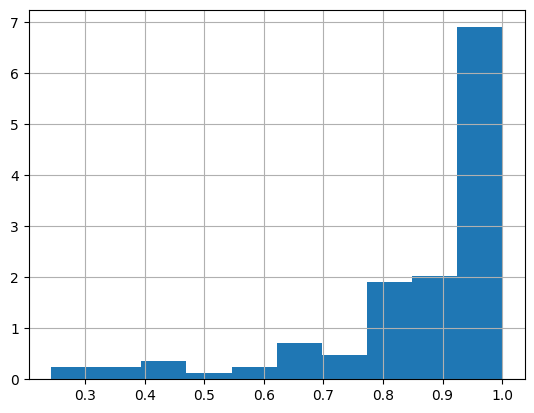

In [18]:
df.score.hist(density = True)

In [9]:
# Filter dataframe for scores not equal to 1 and sort by score in descending order
filtered_df = df[df['score'] != 1].sort_values(by='score', ascending=False)

# Reorder columns: claude_ocr, Ground_Truth, score, length
columns_ordered = ['claude_ocr', 'Ground_Truth', 'score', 'length']
filtered_df_ordered = filtered_df[columns_ordered]

# Display all values
print("Filtered dataframe with scores != 1 (sorted by score descending):")
print("Columns: claude_ocr | Ground_Truth | score | length")
print(filtered_df_ordered)

# Save to CSV file with reordered columns
output_file = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_claude_pcmb/Physics/filtered_results_phy.csv"

filtered_df_ordered.to_csv(output_file, index=False)

print(f"\nResults saved to: {output_file}")
print(f"Number of rows with score != 1: {len(filtered_df_ordered)}")
print("CSV columns order: claude_ocr, Ground_Truth, score, length")


Filtered dataframe with scores != 1 (sorted by score descending):
Columns: claude_ocr | Ground_Truth | score | length
                                            claude_ocr  \
66   05) (2) both assertion and reason are true but...   
21   7. (a) water is optically denser medium compar...   
40   4.(i) principal focus of spherical mirror - wh...   
28   ans2. u = -10cm m = -3 m = v/u -3 = v/-10 v = ...   
30   ans4. (i) focus:- after reflection where the p...   
..                                                 ...   
49   7 the fuse used in the circuit is lowering of ...   
109  => 1/v = 21-20/420 => 1/v = 1/420 => v = 420 c...   
14   4. v = 50cmheight of image = hi givenheight of...   
90   7) circuit symbol of five important components...   
50   defect is hypermetropia. power = 2.67 d focal ...   

                                          Ground_Truth     score  length  
66   q5) (2) both assertion and reason are true but...  0.987654      97  
21   7. (a) water is optically dens